# `mrt_experience` — the robot's live sensory window

`mrt_experience` is the robot's sense of **now**: a short, sliding window over the
raw sensor feed, assembled **in memory** and handed to the LLM to interpret. It is
*reality* — raw frame + raw audio — and nothing derived.

It is **not** a stored table or a batch (DBT) job. It is a rolling buffer of the
**last ~5 seconds**, always ending at the current frame, rebuilt on demand.

**Data source:** Darab's frame API. His GUI (real robot *or* sim mode) serves the
latest sensor snapshot over HTTP on `localhost:8787`; we consume it with his own
client, `logots_api.get_latest_frame()` — exactly as he intended, no wrapper.

## How to run

1. Start Darab's GUI (env `logots`): `python src/logots_ui.py`
2. Click **▶ SIM**, pick a recording CSV (e.g. `experiments/staging_to_action/raw/session_20260713_152211.csv`), leave **LOOP** on.
3. Run this notebook top-to-bottom with the **Python (gemma-lab)** kernel.

The GUI is the running robot; this notebook is our consumer.

## 1. Connect to Darab's API

We pull one frame to confirm the link. `get_latest_frame()` returns the *latest*
snapshot as a dict (`frame_id`, `timestamp`, `image` as RGB, `audio_samples`, …).

In [1]:
import sys, time, threading
from collections import deque
from datetime import datetime

import numpy as np

sys.path.insert(0, "/Users/asaphbrosh/Documents/Projects/Plantaf/src")          # Darab's client lives in src/
from logots_api import get_latest_frame

AUDIO_RATE = 16000                    # Hz — the mic rate (confirmed from recordings)

f = get_latest_frame()                # hits localhost:8787 — his running GUI
print("connected — sim_mode:", f["sim_mode"])
print("frame_id:", f["frame_id"], "| image:", None if f["image"] is None else f["image"].shape,
      "| audio samples this frame:", len(f["audio_samples"]))

connected — sim_mode: True
frame_id: 226 | image: (640, 640, 3) | audio samples this frame: 1536


## 2. How fast does the feed arrive?

This sets how we build the window. We measure the **live** delivery rate rather
than assume it. Two things matter:

- each call returns only the **latest** frame's audio chunk, so if we poll slower
  than frames arrive we **permanently lose** the audio in between;
- therefore we must poll **faster** than the frame rate to stitch gapless audio.

In [2]:
# Poll ~100 Hz for a few seconds; record the time of each *new* frame_id.
t_end = time.time() + 4.0
stamps, ids, last = [], [], None
while time.time() < t_end:
    fr = get_latest_frame(decode_image=False)      # skip decode — timing only
    if fr["frame_id"] != last:
        stamps.append(time.time()); ids.append(fr["frame_id"]); last = fr["frame_id"]
    time.sleep(0.01)

dt = np.diff(stamps); gaps = np.diff(ids)
print(f"new frames: {len(ids)} in {stamps[-1]-stamps[0]:.1f}s")
print(f"frame_id gaps: min={gaps.min()} max={gaps.max()}  (1 = nothing missed)")
print(f"interval: mean={dt.mean()*1000:.0f}ms  min={dt.min()*1000:.0f}  max={dt.max()*1000:.0f}")
print(f"==> live rate ~ {1/dt.mean():.1f} frames/sec (irregular — timestamps are the truth)")

new frames: 44 in 4.0s
frame_id gaps: min=1 max=1  (1 = nothing missed)
interval: mean=92ms  min=52  max=127
==> live rate ~ 10.9 frames/sec (irregular — timestamps are the truth)


## 3. The sliding window

The window holds the **last N seconds ending now**. It *slides* forward with every
new frame — it does **not** chop time into separate 5-second blocks. That matters:
the 5 seconds is only how far **back** the LLM looks, never how long the robot
**waits**. The buffer is always full, so a decision can fire at any instant and get
its 5 s of context immediately.

`push()` dedupes on `frame_id` (we poll faster than frames arrive, so we'd
otherwise re-add the same frame) and trims anything older than `window_s`.

In [3]:
class RollingWindow:
    """Last `window_s` seconds of frames, held in memory. Thread-safe."""
    def __init__(self, window_s=5.0):
        self.window_s = window_s
        self._buf = deque()
        self._last_id = None
        self._lock = threading.Lock()

    @staticmethod
    def _epoch(ts): return datetime.fromisoformat(ts).timestamp()

    def push(self, frame):
        with self._lock:
            if frame["frame_id"] == self._last_id:      # dedupe: same latest frame
                return False
            self._last_id = frame["frame_id"]
            self._buf.append(frame)
            now = self._epoch(frame["timestamp"])
            while len(self._buf) > 1 and now - self._epoch(self._buf[0]["timestamp"]) > self.window_s:
                self._buf.popleft()                     # trim: drop what's too old
            return True

    def assemble(self):
        """The current mrt_experience record: raw frame + stitched raw audio."""
        with self._lock:
            if not self._buf:
                return None
            latest = self._buf[-1]
            audio = np.concatenate([np.asarray(fr["audio_samples"], np.float32) for fr in self._buf])
            span = self._epoch(latest["timestamp"]) - self._epoch(self._buf[0]["timestamp"])
            first_id, last_id, n = self._buf[0]["frame_id"], latest["frame_id"], len(self._buf)
            return {
                "first_frame_id": first_id,              # oldest frame in the window
                "last_frame_id":  last_id,               # newest frame in the window
                "frame":    latest["image"],             # raw camera frame (RGB)
                "audio":    audio,                       # raw mic, stitched @ 16 kHz
                "window_s": round(span, 2),
                "n_frames": n,
                "dropped":  (last_id - first_id + 1) - n,  # frames missing → audio lost (0 = none)
            }

## 4. Capture one full pass

A background thread polls the API ~100 Hz and feeds the window — this is the piece
Darab left to us: he serves the latest frame, we accumulate it.

To capture the **whole recording** cleanly we use `frame_id`: the sim loops, so the
first time the id jumps **backwards** we are exactly at the recording's start — we
begin collecting there and stop at the **next** wrap. That gives one full pass, start
to end. (On the real robot the id only climbs, so this just runs live.)

Across the pass we assemble one `mrt_experience` record every 2 s — the **trace**.
We don't persist the raw frames/audio (ephemeral; Darab's recording already keeps
them); the trace is a compact debug log that becomes the decision log once Gemma is
wired.

In [4]:
window = RollingWindow(window_s=5.0)
_stop, _synced, _wrapped = threading.Event(), threading.Event(), threading.Event()

def _poll_loop():
    last, synced = None, False
    while not _stop.is_set():
        try:
            fr = get_latest_frame(decode_image=True)
        except Exception:
            time.sleep(0.01); continue                  # 503 before first frame / transient
        if last is not None and fr["frame_id"] < last:  # recording looped
            if not synced:
                synced = True; _synced.set()            # 1st wrap → at the recording's start
            else:
                _wrapped.set(); break                   # 2nd wrap → full pass captured
        last = fr["frame_id"]
        if synced:
            window.push(fr)                             # collect only the clean pass
        time.sleep(0.01)                                # ~100 Hz, above the ~10 Hz feed

poller = threading.Thread(target=_poll_loop, daemon=True)
poller.start()
print("syncing to the recording's start…")
_synced.wait(timeout=45)

CADENCE_S, trace, sample, exp_id = 2.0, [], None, 0
while not _wrapped.is_set():
    r = window.assemble()
    if r is not None:
        exp_id += 1
        trace.append({
            "experience_id": exp_id,
            "ts": datetime.now().strftime("%H:%M:%S.%f")[:-3],   # when this experience was formed
            "first_frame_id": r["first_frame_id"], "last_frame_id": r["last_frame_id"],
            "n_frames": r["n_frames"], "window_s": r["window_s"],
            "audio_s": round(r["audio"].shape[0] / AUDIO_RATE, 2),
            "audio_rms": round(float(np.sqrt(np.mean(r["audio"]**2))), 4),
            "dropped": r["dropped"],
        })
        if r["window_s"] >= 4.8:
            sample = r                                  # stash a full-window record to show
    if _wrapped.wait(timeout=CADENCE_S):                # sleep 2 s, or break early on wrap
        break

_stop.set()
import pandas as pd
print(f"one full pass: {len(trace)} experiences, "
      f"frames {trace[0]['first_frame_id']}→{trace[-1]['last_frame_id']}, "
      f"dropped total: {sum(t['dropped'] for t in trace)}, ended on wrap: {_wrapped.is_set()}")
pd.DataFrame(trace)

syncing to the recording's start…
one full pass: 20 experiences, frames 87→486, dropped total: 0, ended on wrap: True


,experience_id,ts,first_frame_id,last_frame_id,n_frames,window_s,audio_s,audio_rms,dropped
0,1,22:55:30.002,87,87,1,0.00,0.06,0.0011,0
1,2,22:55:32.003,87,108,22,1.96,2.02,0.0014,0
2,3,22:55:34.009,87,129,43,3.94,4.00,0.0017,0
3,4,22:55:36.016,97,149,53,5.00,5.06,0.0028,0
4,5,22:55:38.022,119,170,52,5.00,5.09,0.0029,0
5,6,22:55:40.029,140,191,52,4.91,4.96,0.0031,0
6,7,22:55:42.034,159,212,54,4.98,5.06,0.0027,0
7,8,22:55:44.038,181,234,54,4.91,4.99,0.0051,0
8,9,22:55:46.044,203,257,55,4.92,4.99,0.0064,0
9,10,22:55:48.051,224,279,56,4.95,5.02,0.0063,0


## 5. One `mrt_experience` record — seen and heard

One row of that trace, in full: a raw frame the LLM can **see** and a ~5 s raw audio
clip it can **hear**, anchored to its frame range (`first_frame_id`–`last_frame_id`).
This is the object we hand the reflective layer.

frames   : 434-486  (53 frames, 4.93s, dropped 0)
frame    : (640, 640, 3) RGB
audio    : 79872 samples = 4.99 s @ 16000 Hz
audio rms: 0.0043


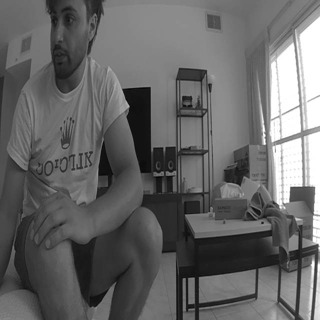

In [5]:
from PIL import Image
from IPython.display import display, Audio

r = sample
print(f"frames   : {r['first_frame_id']}-{r['last_frame_id']}  ({r['n_frames']} frames, {r['window_s']}s, dropped {r['dropped']})")
print(f"frame    : {r['frame'].shape} RGB")
print(f"audio    : {r['audio'].shape[0]} samples = {r['audio'].shape[0]/AUDIO_RATE:.2f} s @ {AUDIO_RATE} Hz")
print(f"audio rms: {np.sqrt(np.mean(r['audio']**2)):.4f}")

display(Image.fromarray(r["frame"]).resize((320, 320)))   # the frame the LLM sees
Audio(r["audio"], rate=AUDIO_RATE)                          # the audio it hears (playable)

## Recap

- `mrt_experience` = a **sliding, in-memory window** over Darab's live API — the
  robot's raw *now* (frame + audio), rebuilt on demand, not stored.
- We poll faster than the ~10 Hz feed so **no audio is lost**; the window keeps the
  **last 5 s ending now**, so lookback never becomes wait-time.
- Raw sensory data stays **ephemeral**; a compact **trace** is what we keep (debug
  today, the event log in production).

**Next step:** hand one `mrt_experience` record (frame + audio) to local Gemma to
interpret and choose an action — the reflective layer.